In [18]:
#pip install torch

In [19]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Parameter
import math

In [21]:
device = 'cpu'

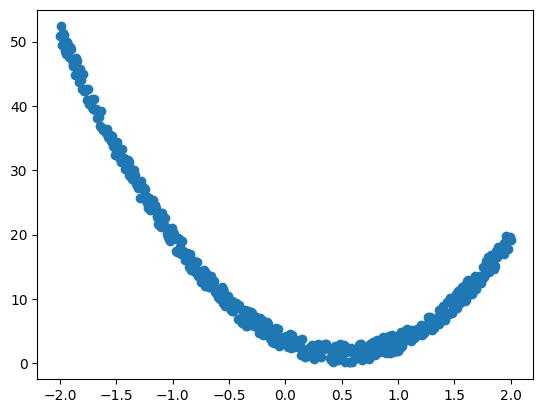

In [38]:
#Create Data

x = torch.linspace(-2, 2, 500)
y = 8*(x-0.5)**2 + 3*torch.rand(x.size())
x = torch.unsqueeze(x, dim=1)
y = torch.unsqueeze(y, dim=1)

plt.scatter(x.data.numpy(), y.data.numpy())
plt.show()

In [23]:
#Create Test Data
x_test = torch.linspace(-2, 2, 500)
y_test = 8*(x_test-0.5)**2 + 3*torch.rand(x_test.size())

x_test = torch.unsqueeze(x_test, dim=1)
y_test = torch.unsqueeze(y_test, dim=1)

In [24]:
class BayesLinear(nn.Module):

    def __init__(self,
                 in_features,
                 out_features,
                 bias = True,
                 weight_prior_mu = 0,
                 weight_prior_sigma = 0.1,
                 bias_prior_mu = 0,
                 bias_prior_sigma = 1.):

        super(BayesLinear, self).__init__()

        self.samples = {'weights' : None, 'bias' : None}

        self.in_features = in_features
        self.out_features = out_features
        self.bias = bias
        self.weight_prior_mu = weight_prior_mu
        self.weight_prior_sigma = weight_prior_sigma
        self.l_weight_prior_sigma = torch.log(torch.tensor(weight_prior_sigma)) # take log of the sigma prior

        self.weights_mu = Parameter(torch.rand(out_features, in_features)-0.5) #initialize mu weights
        self.lweights_sigma = Parameter(torch.log(weight_prior_sigma*torch.ones(out_features, in_features))) # intialize log weights for sigma

        if self.bias:
            self.bias_prior_mu = bias_prior_mu
            self.bias_prior_sigma = bias_prior_sigma
            self.bias_mean = Parameter(torch.rand(out_features)-0.5) # intialize bias mean if given
            self.lbias_sigma = Parameter(torch.log(bias_prior_sigma* torch.ones(out_features))) # intialize bias sigma



    def getSampledWeights(self):
        return self.samples['weights']

    def getSampledBias(self):
        return self.samples['bias']

    def kl_div(self, mu_q, sigma_q, mu_p, sigma_p):
        kl = sigma_p - sigma_q + (torch.exp(sigma_q)**2 + (mu_q - mu_p)**2) / (2 * math.exp(sigma_p)**2) - 0.5  # Kullback Leibler divergence for two normals

        return kl.mean()


    def forward(self, x):

        self.samples['weights'] = self.weights_mu + torch.exp(self.lweights_sigma) * torch.randn_like(self.lweights_sigma) #training with stochastic gradient ascent

        kl = self.kl_div(self.weights_mu, self.lweights_sigma, self.weight_prior_mu, self.l_weight_prior_sigma)

        if self.bias:

          self.samples['bias'] = self.bias_mean + torch.exp(self.lbias_sigma) * torch.randn_like(self.lbias_sigma)
          kl += self.kl_div(self.bias_mean, self.lbias_sigma, self.bias_prior_mu, self.bias_prior_sigma)


        out = F.linear(x, self.samples['weights'], self.samples['bias'] if self.bias else None) # return linear


        return out, kl

# The Kullback Leibler Divergence for two Normals:

$KL(X||Y) = log \frac{σ_Y}{σ_X} + \frac{σ²_X + (μ_X - μ_Y)²}{2σ²_Y} - \frac{1}{2}$

# Stochastic Gradient Ascent:

Standard MAP Neural Network training:

$L(w) = \mathbb{E}_{x,y \sim D} [\log p(\hat{y}(x) = y|w) + \log p(w)]$

If we want to maximize the ELBO for VI this becomes:

$L(μ, σ) = \mathbb{E}_{x,y \sim D} [\mathbb{E}_{w \sim q_{\mu, σ}} [\log p(\hat{y}(x) = y|w) + \log p(w) - \log q_{μ, σ}(w)]]$

applying this to the standard training algorithm, where the weights are updated as:

$w = w + αg$

and assuming assuming prior

$w \sim \mathbb{N}(μ, σI) = μ + σϵ$ with $ϵ \sim \mathbb{N}(0, I)$


the algortihm becomes:

$ϵ \sim \mathbb{N}(0, I)$

$w = w + αg$

$σ = σ + \alphaϵg$

In [25]:
def validate(model, val_loader, loss_fun, n_samples):

    val_loss = []

    model.eval()

    with torch.no_grad():
        for i, batch in enumerate(val_loader):

            input, target = batch

            target = target.to(device)
            input = input.to(device)

            output = []
            kl_div = []

            for sample in range(n_samples):
                out, kl = model(input)
                output.append(out)
                kl_div.append(kl)

            mean_pred = torch.mean(torch.stack(output), dim = 0)
            kl_loss = torch.mean(torch.stack(kl_div), dim = 0)
            log_lik_loss = loss_fun(mean_pred, target)
            loss = log_lik_loss + kl_loss
            val_loss.append(loss.cpu())

        mean_loss = np.mean(np.array(val_loss))

    return mean_loss



def train(model, optimizer, loss_fun, trainset, device, n_epochs, batch_size, n_samples, print_mod = 1):

    loss_lis = []
    overall_loss = []
    val_loss = []

    model = model.to(device)

    for epoch in range(n_epochs):

        for i, batch in enumerate(trainset):

            x, y = batch
            x = x.to(device)
            y = y.to(device)

            output = []
            kl_div = []

            for _ in range(n_samples):  #Not sure if sampling here is needed check that
                out, kl = model(x)
                output.append(out)
                kl_div.append(kl)

            # out, kl = model(x)


            mean_pred = torch.mean(torch.stack(output), dim = 0)
            kl_loss = torch.mean(torch.stack(kl_div), dim = 0)

            #print(kl_loss)

            loss = loss_fun(mean_pred, y)
            scaled_kl = kl_loss/batch_size
            loss += scaled_kl  #ELBO Loss add if loos_fun is negative log_likelihood

            #loss = loss_fun(out, y)
            #loss += kl * 0.1     # Why does this improve training so much? kl / batch_size and add sampling again


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_lis.append(loss.cpu().detach())

        if epoch % print_mod == 0:

            mean_loss = np.mean(np.array(loss_lis))
            overall_loss += mean_loss
            loss_lis = []

            #validation_loss = validate(model, valset, loss_fun, n_samples)

            #val_loss.append(validation_loss)


            print(f'Epoch nr {epoch}: mean_train_loss = {mean_loss}')
            #, , validation_loss =  {validation_loss}')

    return overall_loss




def sample(model, n_samples, testloader):

  model.eval()
  mean_pred_list = []
  std_list = []

  with torch.no_grad():

    for i, batch in enumerate(testloader):

      output_mc = []

      data, target = batch

      data = data.to(device)
      target = target.to(device)

      for _ in range(n_samples):
        out, _ = model.forward(data)
        output_mc.append(out)

      output = torch.stack(output_mc)

      mean_pred_batch = torch.mean(output, dim = 0)
      std_batch = torch.sqrt(torch.var(output, dim = 0))
      mean_pred_list.append(mean_pred_batch)
      std_list.append(std_batch)

  return mean_pred_list, std_list

In [26]:
batch_size = 100

In [27]:
#train_set = CustomDataset_img_features(x, y)
#test_set = CustomDataset_img_features(x_test, y_test)

train_set = list(zip(x, y))
test_set = list(zip(x_test, y_test))


train_loader = torch.utils.data.DataLoader(train_set, batch_size = batch_size, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = batch_size, shuffle = False)

In [28]:
class Model(nn.Module):
  def __init__(self, in_features, out_features):
    super(Model, self).__init__()

    self.layer1 = BayesLinear(in_features = in_features, out_features=100)
    self.activation = nn.ReLU()
    self.layer2 = BayesLinear(in_features=100, out_features= out_features)

  def forward(self, x):

    kl_sum = 0

    out, kl = self.layer1(x)
    kl_sum += kl
    out = self.activation(out)

    out, kl = self.layer2(out)

    kl_sum += kl

    return out, kl_sum

In [29]:
model = Model(in_features = 1, out_features = 1)

In [30]:
mse_loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [31]:
total_loss = train(model = model, optimizer = optimizer, loss_fun = mse_loss, trainset = train_loader, device = device, n_epochs = 500, batch_size = batch_size, n_samples = 10, print_mod = 100)

Epoch nr 0: mean_train_loss = 292.04522705078125
Epoch nr 100: mean_train_loss = 20.53423500061035
Epoch nr 100: mean_train_loss = 20.53423500061035
Epoch nr 200: mean_train_loss = 2.264207601547241
Epoch nr 200: mean_train_loss = 2.264207601547241
Epoch nr 300: mean_train_loss = 1.988412857055664
Epoch nr 300: mean_train_loss = 1.988412857055664
Epoch nr 400: mean_train_loss = 1.773601770401001
Epoch nr 400: mean_train_loss = 1.773601770401001


In [32]:
mean_prediction, standard_dev  =  sample(model, n_samples = 3, testloader= test_loader)

In [33]:
mean = torch.cat(mean_prediction, dim = 0).cpu().numpy()

In [34]:
std = torch.cat(standard_dev, dim = 0).cpu().numpy()

In [35]:
plus_error = mean + 2* std

In [36]:
minus_error = mean - 2* std

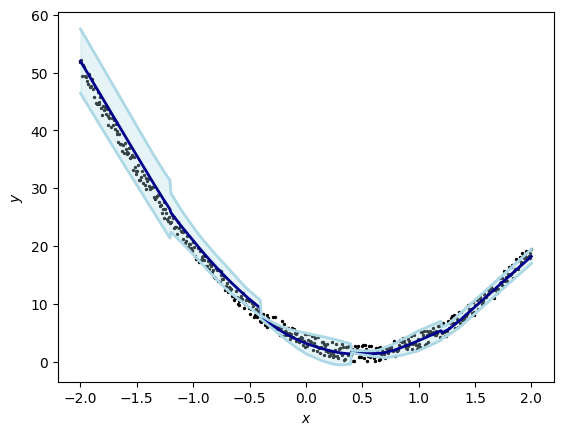

In [37]:
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

plt.scatter(x_test.data.numpy(), y_test.data.numpy(), color='k', s=2)

# Dark blue for mean prediction
plt.plot(x_test.data.numpy(), mean, color='darkblue', linewidth=2, label='Mean Prediction')

# Light blue for error bounds
plt.plot(x_test.data.numpy(), plus_error, color='lightblue', linewidth=2, label='Upper Bound')
plt.plot(x_test.data.numpy(), minus_error, color='lightblue', linewidth=2, label='Lower Bound')

# Light blue shaded area between error bounds
plt.fill_between(x_test.data.numpy().squeeze(), plus_error.squeeze(), minus_error.squeeze(), color='lightblue', alpha=0.3, label='Confidence Interval')